# Huấn luyện mô hình Logistic Regression

Dataset: `Leads_Selected_Train.csv` và `Leads_Selected_Test.csv`
- Sử dụng GridSearchCV để tìm tham số tối ưu.
- Đánh giá bằng Accuracy, Precision, Recall, F1.
- Vẽ và lưu Confusion Matrix, ROC-AUC Curve.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)

os.makedirs('results_img', exist_ok=True)

sns.set_theme(style='whitegrid')

## 1. Đọc dữ liệu

In [7]:
df_train = pd.read_csv('Leads_Selected_Train.csv')
df_test = pd.read_csv('Leads_Selected_Test.csv')

X_train = df_train.drop(columns=['Converted'])
y_train = df_train['Converted']

X_test = df_test.drop(columns=['Converted'])
y_test = df_test['Converted']

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (6152, 6)
Kích thước tập Test: (1538, 6)


## 2. Tìm kiếm tham số (GridSearchCV)

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

lr = LogisticRegression(random_state=42, max_iter=1000)

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nTham số tốt nhất: {grid_search.best_params_}")
print(f"F1 Score tốt nhất (Cross-validation): {grid_search.best_score_:.4f}")

# Lưu mô hình tốt nhất
best_lr = grid_search.best_estimator_
joblib.dump(best_lr, 'best_model_logistic_regression.pkl')
print("Đã lưu mô hình tối ưu thành file 'best_model_logistic_regression.pkl'")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Tham số tốt nhất: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
F1 Score tốt nhất (Cross-validation): 0.6766
Đã lưu mô hình tối ưu thành file 'best_model_logistic_regression.pkl'


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 3. Đánh giá trên tập Test

In [9]:
y_pred = best_lr.predict(X_test)
y_pred_proba = best_lr.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=== Kết quả Đánh giá Logistic Regression trên Test Set ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

=== Kết quả Đánh giá Logistic Regression trên Test Set ===
Accuracy  : 0.7718
Precision : 0.7446
Recall    : 0.6346
F1 Score  : 0.6852
ROC-AUC   : 0.8463


## 4. Trực quan hóa (Confusion Matrix & ROC Curve)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


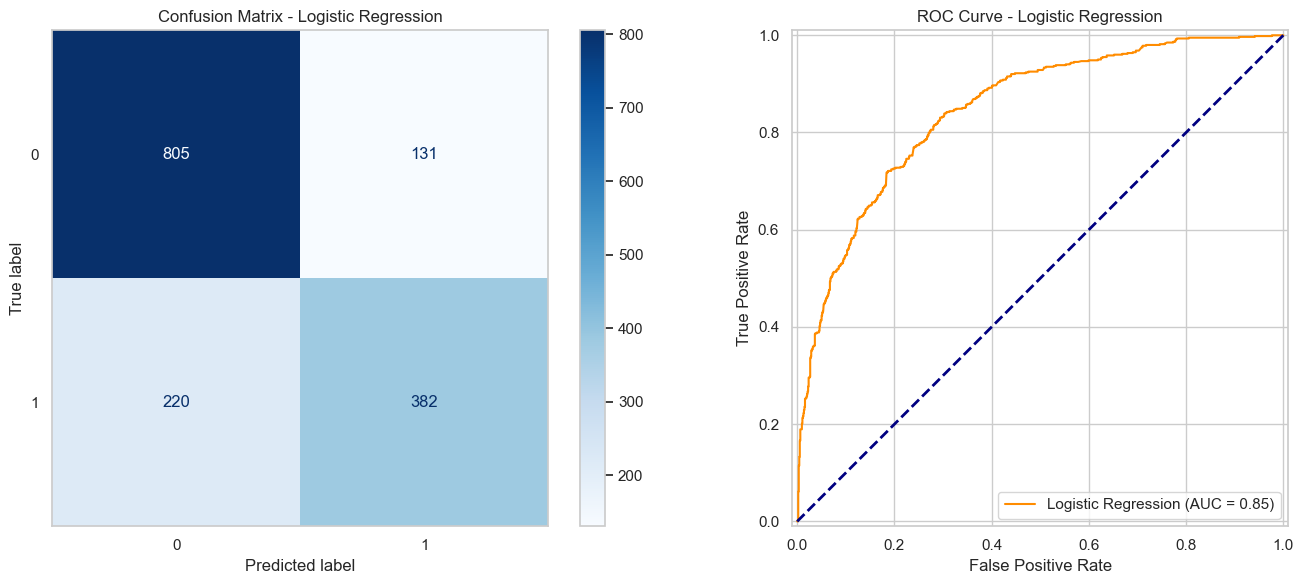

Đã lưu biểu đồ thành 'results_img/LogisticRegression_Evaluation.png'


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_lr.classes_)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].grid(False)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='Logistic Regression')
roc_display.plot(ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('ROC Curve - Logistic Regression')

plt.tight_layout()
plt.savefig('results_img/LogisticRegression_Evaluation.png', dpi=300)
plt.show()

print("Đã lưu biểu đồ thành 'results_img/LogisticRegression_Evaluation.png'")